### Deconvolution approach to filter the noise of the data, then measuring the ARI

Summary: Ultimately what we are doing is bringing our noisy data that is in the time domain to the frequency domain and breaking it up into the frequencies that make it up, then we are getting rid of the noisy (high and staggering) frequencies and then inversing the operations to get the non noisy points as the output

Imports

In [137]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np
from hdbscan import HDBSCAN
from sklearn.metrics import adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
from fast_hdbscan.boruvka import sample_weight_core_distance
from scipy.interpolate import interp1d
import scipy

Dataset

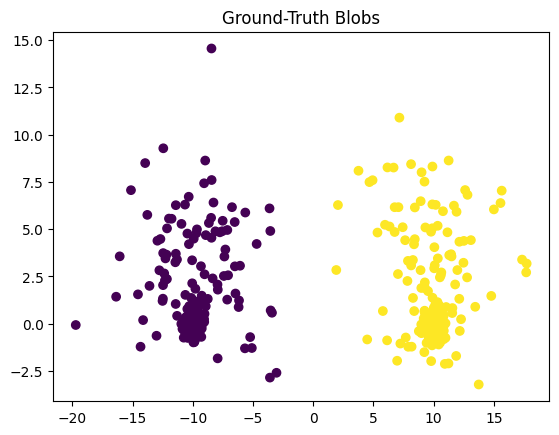

In [138]:
centers = [[-10.0, 0.0], [-10.0, 3.0], [10.0, 0.0], [10.0, 3.0]]
clusters_std = [0.5, 3.0, 0.5, 3.0]

n_per_comp = [100, 100, 100, 100]

X, raw_labels = make_blobs(
    n_samples = n_per_comp,
    centers = centers,
    cluster_std = clusters_std,
    random_state = 42
)

true_labels = raw_labels // 2

plt.scatter(X[:,0], X[:,1], c=true_labels, cmap='viridis')
plt.title("Ground-Truth Blobs")
plt.show()

Noisy dataset

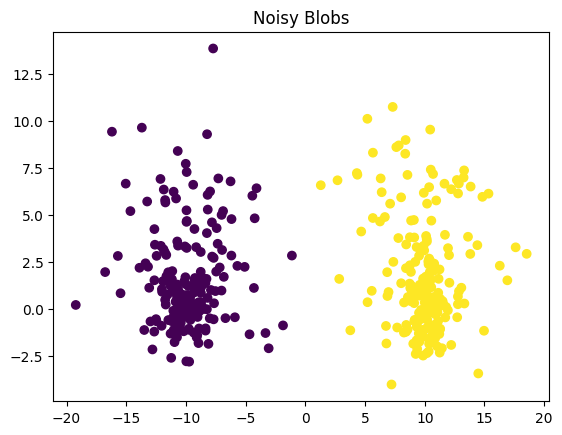

In [139]:
std = 1.0
X_obs = X + np.random.normal(scale=std, size=X.shape)

plt.scatter(X_obs[:,0], X_obs[:,1], c=true_labels, cmap="viridis")
plt.title("Noisy Blobs")
plt.show()

### Making a grids for our data
- The first grid is for the points in the data domain while the second grid is for the points in the frequency domain

- The M variable is the number of gridpoints in the domain we are estimating the desnisty on
    - The reason we use 512 is because fast fourier transforms work best with power of 2 lengths, this is the closest powr of 2 to 400 which is the number of datapoints we have
        * To try in the future: Make it so it is adaptable to the amount of data points you use

- We use a buffer to add an added margin around the grid which helps prevent edge effects

- To form our grids we use linspace to create a regularly spaced grid over our interval

- t_grid represents the grid for our frequencies (in radians per unit), so we need our distance in the fft.freq function which turns our distance for our grid into 1/seperation and then we multiply by 2pi to turn them into radian values

In [140]:
x_size, M = len(X_obs), 2**9

buffer = 0.1 * (X_obs.max() - X_obs.min())

x_min = X_obs.min() - buffer
x_max = X_obs.max() + buffer

x_grid = np.linspace(x_min, x_max, M)

seperation = x_grid[1] - x_grid[0]

t_grid = 2 * np.pi * np.fft.fftfreq(M, d=seperation)

### Tricube kernel for compact support and smoothness
- Our parameter is t_scaled because we scale our data points in the frequency domain t by our threshold smoothing value h (which we will assess for calculations shortl)

- The reason for our operation with inner where we make any values > 1 or < -1 equal to 0, since our interval is [-1:1], this is because we only wan tto keep the frequency components near 0. This is done because the low frequency component of our data represents the broad, smooth, structure of the data. While the high frequency components represents the noise

- To calculate h we minimize an apporximation of the AMISE (Asymptotic Mean Integrated Squared Error), 
    * Since we know are noise is gaussian we use this specific formula, but is there a way to construct a formula that can adapt to any noise?

- phi_K represents the fourier transform of the kernel function, we want this because when we convolve a kernel with data in real space, it becomes multiplication in the frequency domain

- The point of the kernel in the algorithm is to stabilize the estimate if there are any wild oscillations or poor estimates

In [141]:
def tricube_kernel_ft(t_scaled):
    u = t_scaled
    inner = (1 - np.abs(u)**3)**3
    inner[np.abs(u) > 1] = 0.0
    return (70 / 81) * inner

h = (np.log(x_size) / x_size)**(1 / 5)

phi_K = tricube_kernel_ft(t_grid * h)

### Computing the empirical characteristic form of our oberved/noisy data and noise

- Computing the empirical characteritisc form of our observed/noisy data means calculating the expected complex exponential e^itX over our data. This brings our data to othe frequency domain and serves as proxy for the fourier transform of the observed density. phi_X = 1/n sigma(n, 1) e^itX, which is not exactly fast fourier transform 

- Computing the fourier transform of the noise involves evaluating the known analytic expression for the characteristic function of the noise. For example, if the noise is Gaussian with variance sigma^2 then then the characteritsic function would be phi_U = e^(-0.5)*sigma^2*t^2. This ste is crucial because in the frequency domain the convolution becomes a multiplication, and deconvolution becomes division. That's why we work in the frequency domain -> To divide out the noise of the observed data 

In [142]:
phi_X = np.mean(np.exp(1j * np.outer(t_grid, X_obs)), axis=1)

phi_U = np.exp(-0.5 * (std ** 2) * (t_grid ** 2))

### Now that we have both the observed data and the noise in the frequency domain we can "deconvolve" our observed data by dividing the observed data by the noise all in the frequency domain. But our estimate could still be noisy, so we smooth it out by multiplying our phi_K by the fourier transform of the kernel, essentially applying. alow pass filter

In [143]:
phi_Y = phi_X / phi_U

smoothed_phi_Y = phi_Y * phi_K

### We can now invert our data from the frequency domain to the data domain

- The shifting done rearranges the array to zero so th efrequency is at the start. This is necessary because np.fft.ifft assumes zero frequency is at the start, then np.fft.ifft computes the inverse fourier transform of the, turning the frequency domain data into data domain data. Which is our estimate desnsity 

- np.real is necessary because it takes only the real part of the data since there are imaginary parts in the frequency domain data

- len(t_grid) / (2* np.pi) rescales the output to our liking

In [144]:
f_hat = np.real(np.fft.ifft(np.fft.ifftshift(smoothed_phi_Y))) * M / (2* np.pi)

### Interpolation of f_hat grid 
- Since f_hat gives us the deconvolved density only at the fixed grid points in t_grid, we don't know the exact values of the density att our actual data points
- To estimate the desnsity at these non-grid locations, we interpolate, which fills the gap between grid points by estimating values in between

In [145]:
interp_func = interp1d(x_grid, f_hat, kind='linear', fill_value="extrapolate")

density_X_obs = interp_func(X_obs[:,0])

### Computation of mutual reachability
- Now that we have a density estimate (f_vals) we can compute our core distances then mutual reachability  
- First we construct a k-nearest neighbours finder onnour observed data, which returns for each point the 5 nearest neighbours
- Then we calculate the core distances by taking the inverse of our density estimate and we add a small number to make sure we are not dividing by zero. The way this works is when the estimated density is large it means the core distance is small, however when the estimated desnity is small the core distance is large 
- The next step is computing the pairwise euclidian distance matrix of shape (n, n) where n = len(X_obs), this is done with the d_obs variable, (distance between observed data points)
- Then we reshape our core distances into 2 1-d arrays, so our mutual reachability can be computed 
- To compute our mutual reachbility we take the maximum of the ocre distance of the points i and j for the (i, j) mutual reachability with the fall back values of our observed data. Basically, we take the most sparse region as our estimate for mutual reachability
- We then comapre our results with vanilla hdbscan using ARI

In [146]:
from fast_hdbscan.boruvka import sample_weight_core_distance

k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_obs)

core_dist_unc = 1.0 / (density_X_obs + 1e-8)

d_obs = np.linalg.norm(
    X_obs[:, None, :] - X_obs[None, :, :],
    axis=2
)

cd_i = core_dist_unc[:, None]   
cd_j = core_dist_unc[None, :]

mutual = np.maximum(np.maximum(cd_i, cd_j), d_obs)

clusterer = HDBSCAN(
    metric='precomputed',
    min_samples=k,
    min_cluster_size=k
)

pred_labels = clusterer.fit_predict(mutual)

ari = adjusted_rand_score(true_labels, pred_labels)
print("ARI (uncertainty-aware, variant 4):", ari)

ARI (uncertainty-aware, variant 4): 0.282279598844852


### Problems:
- When the clusters are close to eachother or have noise larger than 1.0 we get nan values since we have a division by zero which originates from....
- 

### Why do we want to see our distribution in the frequency domain??

The reason we want to see our distribution in the frequency domain is because the frequency domain has special properties, where for example convolution becomes multiplication

Ex: If Y is your true data and U is your noise, your observations are: X = Y + U, where the probabbility densisty function is the convolution of f(y) and f(u)

In the frequency domain X = Y + U is -> $X(t) = $Y(t) * $U(t), so if we know $X(t) and $U(t) where $U(t) is the noise distribution, we can do the opertation $Y(t) = $X(t)/$U(t) to remove the noise. Also reffered to as "Deconvolution"

### To say:

- After running tests for: Noise level of 1.5 for 2‑component Gaussian mixture with dual‑spread overlays (8 points a part (euclidian distance from mean to mean)), I noticed that HDBSCAN simply with a probability rank matrix can be risky and can sometimes score a very low or very high ARI (but stays around the same on average), but adding our threshold avoids this risk and even when the probabaility rank matrix HDBSCAN performed poorly the threshold probabaility rank amtrix performed well (normally). 
    - In summary: The threshold for the proabbailtiy rank matrix can basically avoid the risk of getting abnormally small or large values, hence it stays around the same more often, but it also gets outperformed often

- Made a list of various datasets we are planning to use, with their real world applications
    - a

### Questions:

- Should we use a different kernel? If so, which one?
    - The reason we we picked to use the tricube kernel is because it has a bandwidth cutoff which is good for blocking out noise

- Is the way we are estimating the bandwidth for KDE ok? (Silverman's rule of thumb adjusted for deconvolution (difference between the variance of our data and the variance of our gaussian noise))
    - We do this method because the variance of the noise adds spread to our estimate, so we are "unspreading" the estimate by taking the difference

- Could we get some insights on how to calculate the deconvolution multiplier, inverter, and interpolator?
    - I was thinking 

- Is our understanding of deconvolution correct?
    - From my understanding deconvolution is bringing our noisy data that is in the time domain to the frequency domain and breaking it up into the frequencies that make it up, then we are getting rid of the noisy (high and staggering) frequencies and then inversing the operations to get the non noisy points as the output

- Does deconvolution method relate to the monte carlo probability rank matrix method?? Do they intersect?
    - a

- What types of problems will this project solve in the real world?
    - Medical indsutry, geospatial imaging, etc? 

- What is an interpolator?
    - Estimate of frequency between 2 points? Should we use it and why? 

### Notes from first meeting about this with professor smith:

Fourier transform of a gaussian is a gaussian 

Rreal orld application -> document retreival 

Interpoltion is just filling in the lines

That is step 1 -> finish the fourier divier/multiplier then do some interpolation if necesssaryy

arxiv for math and stuff

Step 2:
- Try to use in 1 dim hdbscn whith 2 gaussians (with a risen valley)
    - You will onlt have the didstanc between points and not the actual position of the points
    - min_cluster size have a theshold that stops sparseclusters (low density) not let the clusrr dm h
    - edit the min_clustrrin the algorithm 
    - (might get reanamed in the code)
    - sklearn signle linkage tree
    - Replace the if statement in min_cluster size where you replafe the sum of 1's by the density of a point
    - the density quals 1/mutual reachiability
- Chets as much as you can with the, 
- Look into fourier transforms with graphs 
- Division. by 0 issue 